In [1]:
%matplotlib widget
#for emcee
import emcee

#for dynesty
import dynesty
from dynesty import utils

#for numpyro
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

#general
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import corner

In [2]:
#initialize a random number generator
rng = np.random.default_rng(1000)

# Pathalogical examples

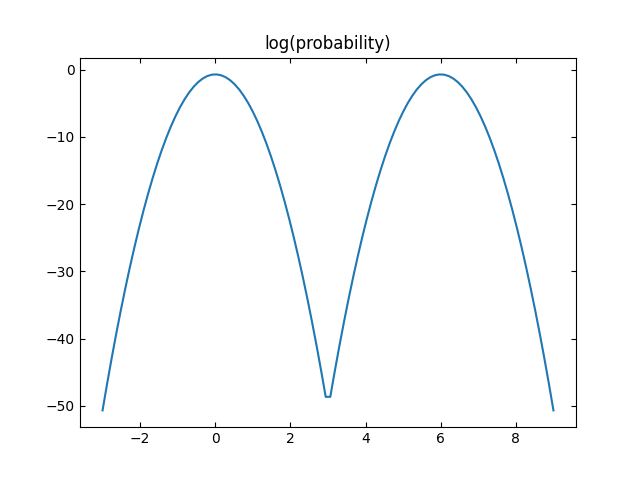

(5000, 20, 1)
Fraction near mode 1 (x<3): 1.0
Fraction near mode 2 (x>3): 0.0
Posterior mean: 0.006172371380521905


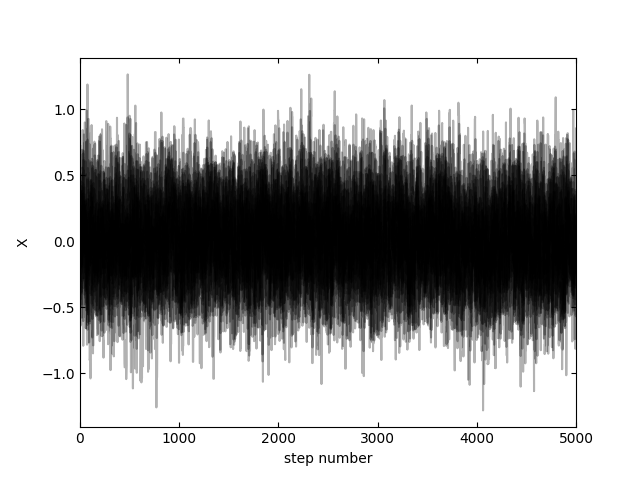

In [3]:
#strongly bimodal posterior that we don't necessarily know about
def lnlike(params):
    x = params[0]
    p1 = np.exp(-0.5 * ((x - 0.0) / 0.3) ** 2)   # mode at x=0
    p2 = np.exp(-0.5 * ((x - 6.0) / 0.3) ** 2)   # mode at x=6
    p = 0.5 * p1 + 0.5 * p2                       # equal weight
    return np.log(p)

def lnprior(params):
    return 0.0 

#ln(probability). Just a combination of the liklihood and prior
def lnprob(params):
    lp = lnprior(params)
    
    #This ensures that points outside the prior are avoided.
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(params) #ln(probability)

#plot!
fig, ax = plt.subplots()
ax.plot(np.linspace(-3,9,100), [lnlike([par,]) for par in np.linspace(-3,9,100)])
ax.set_title('log(probability)')
plt.show()


ndim, nwalkers = 1, 20
p0 = 0.0 + 0.1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob)
sampler.run_mcmc(p0, 5000, progress=False)

samples = sampler.get_chain()#[:, 0]
print(samples.shape)
print("Fraction near mode 1 (x<3):", np.mean(samples < 3))   # → 1.0
print("Fraction near mode 2 (x>3):", np.mean(samples > 3))   # → 0.0
print("Posterior mean:", np.mean(samples))                    # ≈ 0.0  (should be ≈3.0)

fig, ax = plt.subplots()
ax.plot(samples[:,:,0], "k", alpha=0.3)
ax.set_xlim(0, len(samples))
ax.set_ylabel('X')
ax.yaxis.set_label_coords(-0.1, 0.5)

ax.set_xlabel("step number");
plt.show()


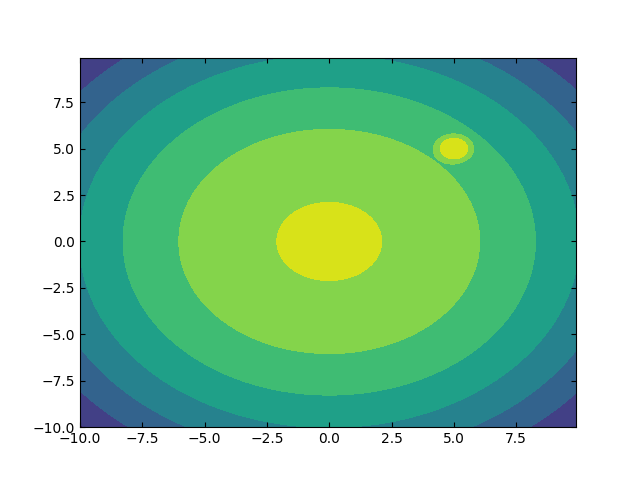

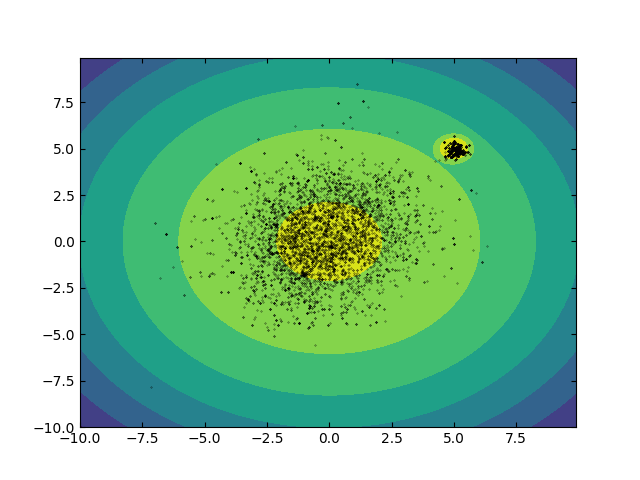

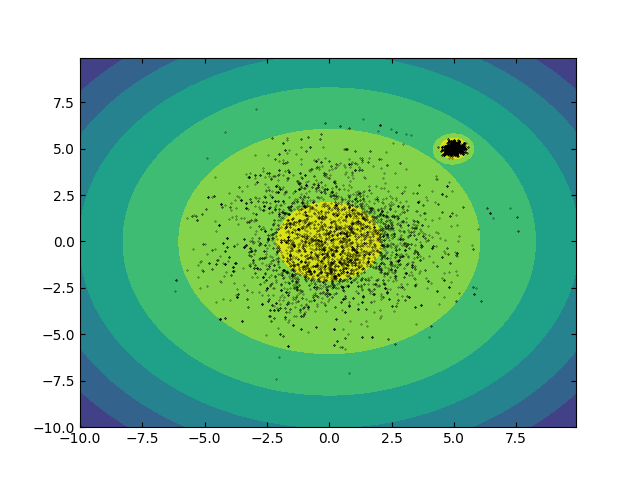

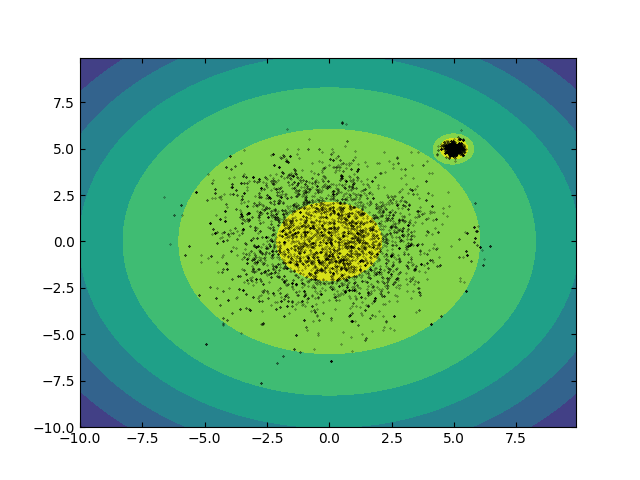

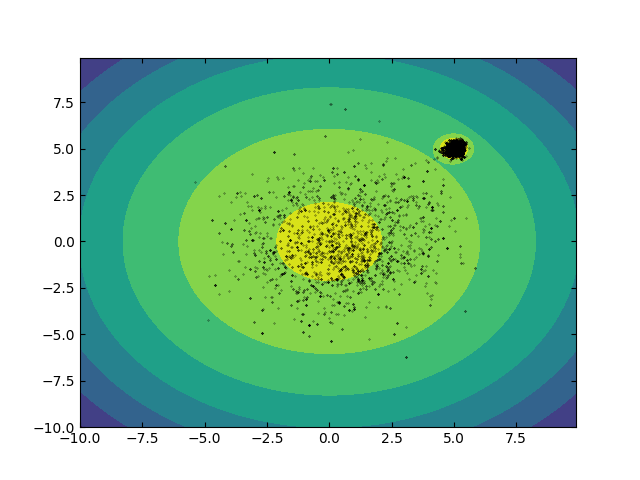

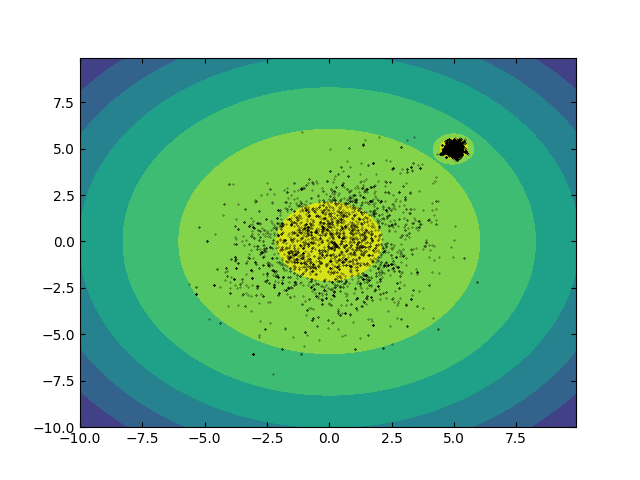

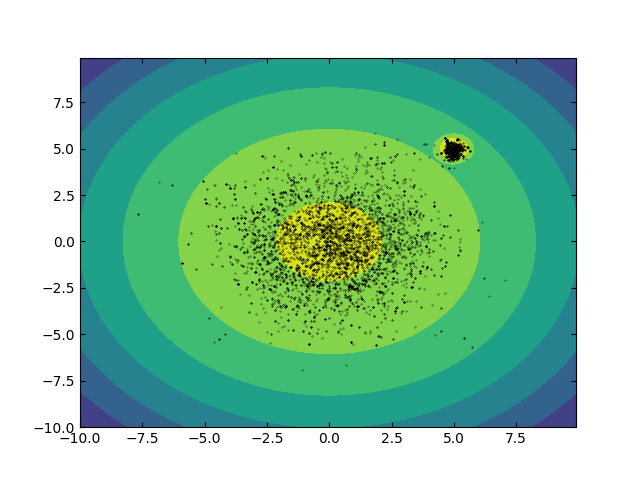

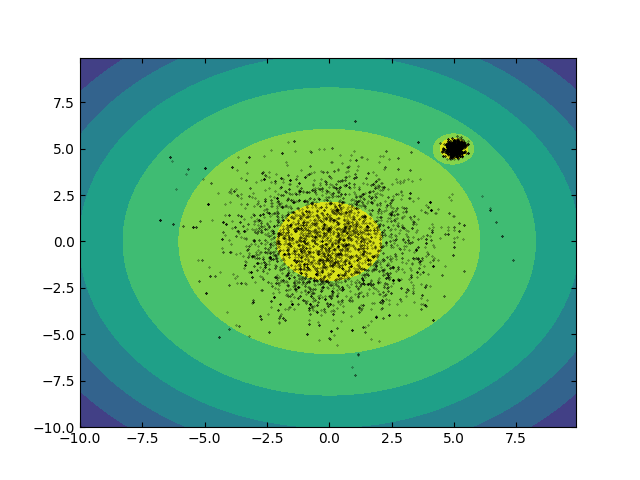

In [4]:
# narrow "true" peak superimposed on a broad underlying distribution with large prior weight
true_peak  = sps.multivariate_normal(mean=[5, 5],   cov=[[0.2**2, 0], [0, 0.2**2]])
decoy_peak = sps.multivariate_normal(mean=[-0, -0], cov=[[2.0**2, 0],  [0, 2.0**2]])

w_true, w_decoy = 0.2, 0.8   # true peak is tall & narrow but low prior weight

#strongly bimodal posterior that we don't necessarily know about
def lnlike(params):
    return np.logaddexp(np.log(w_true) + true_peak.logpdf(params),
                         np.log(w_decoy) + decoy_peak.logpdf(params))

def lnprior(params):
    x, y = params
    if -10.0 < x < 10.0 and -10.0 < y < 10.0:
        return 0.0 #ln(prior)
    return -np.inf

#ln(probability). Just a combination of the liklihood and prior
def lnprob(params):
    lp = lnprior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(params) #ln(probability)


#evaluate the function on a grid to show it
x, y = np.mgrid[-10:10:0.1, -10:10:0.1]
grid = np.dstack((x, y))

fig, ax = plt.subplots()
ax.contourf(x, y, lnlike(grid))
plt.show()


ndim, nwalkers = 2, 60
nsamples=1000
p0 = np.random.uniform(-10, 10, size=(nwalkers, ndim))   # broad, uninformed init

sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob)
sampler.run_mcmc(p0, nsamples, progress=False)                # "reasonable" burn-in
pos, lp = sampler.get_chain()[-1], sampler.get_log_prob()[-1]

isamples = sampler.get_chain(flat=False)

fig, ax = plt.subplots()
ax.contourf(x, y, lnlike(grid))
ax.plot(isamples[:,:,0].flatten()[::10], isamples[:,:,1].flatten()[::10], 'k.', ms=0.5)
plt.show()


# repeatedly reinitialize the worst 25% to the current best walker
for round in range(6):
    best_idx = np.argmax(lp)

    #find the worst 25%
    worst_pct = np.percentile(lp, 50)
    worst_idx = np.where(lp <= worst_pct)

    pos[worst_idx] = pos[best_idx]

    sampler.reset()
    sampler.run_mcmc(pos, nsamples, progress=False)
    pos, lp = sampler.get_chain()[-1], sampler.get_log_prob()[-1]
    isamples = sampler.get_chain(flat=False)
    
    fig, ax = plt.subplots()
    ax.contourf(x, y, lnlike(grid))
    ax.plot(isamples[:,:,0].flatten()[::10], isamples[:,:,1].flatten()[::10], 'k.', ms=0.5)
    plt.show()

# Line fitting example

Fist generate some fake data. This is a simple line with randomly generated noise properties and a value-dependent additional offset.

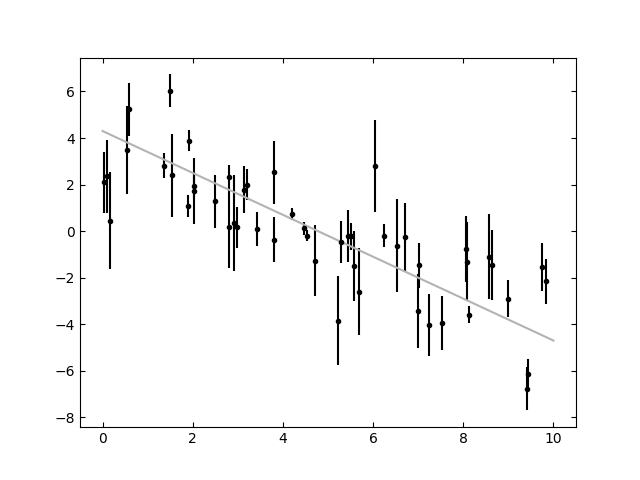

In [5]:
# given some set of ``true'' parameters.
m_true = -0.9
b_true = 4.3
f_true = 0.5

# Generate some points from our line
N = 50
x = np.sort(10 * rng.random(N)) # uniform random points between 0 and 10
yerr = 0.1 + 2.0 * rng.random(N) # generate a uniform random error (standard deviation) between 0.1 and 2.1
y = m_true * x + b_true # array of exact y values correspond to x for the true parameters.
y += yerr * rng.standard_normal(N) # perturb the exact y values according to yerr
y += np.abs(f_true * y) * rng.standard_normal(N) #random noise that depends on y

#plot the data
fig, ax = plt.subplots()
ax.errorbar(x, y, yerr=yerr, fmt='k.')

#plot our "truth" line
x_ref = np.linspace(0,10, 100)
ax.plot(x_ref, m_true*x_ref + b_true, '-', color='0.7')

plt.show()


## Example code 1 - using emcee

/Users/jtmendel/.pyenv/versions/3.12.13/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


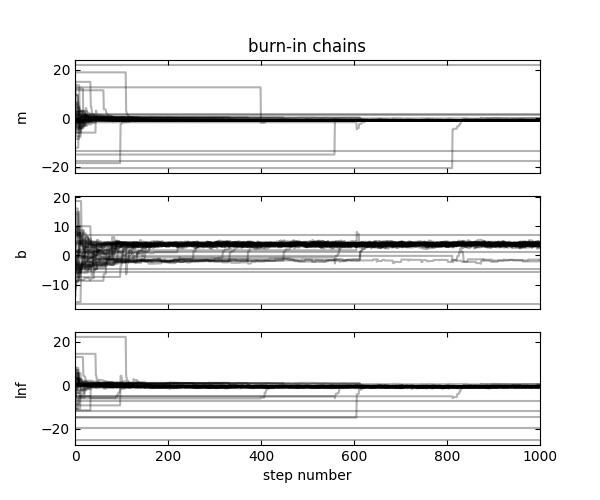

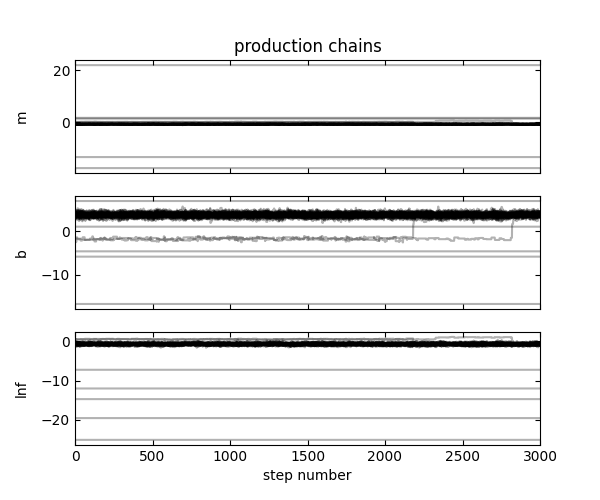

/Users/jtmendel/.pyenv/versions/3.12.13/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


Autocorrelation length: nan


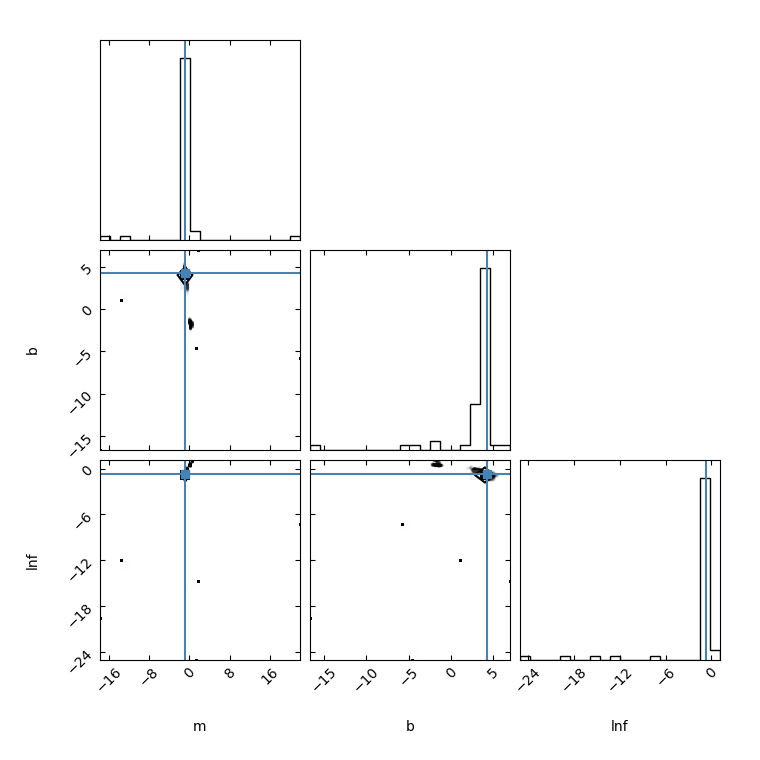

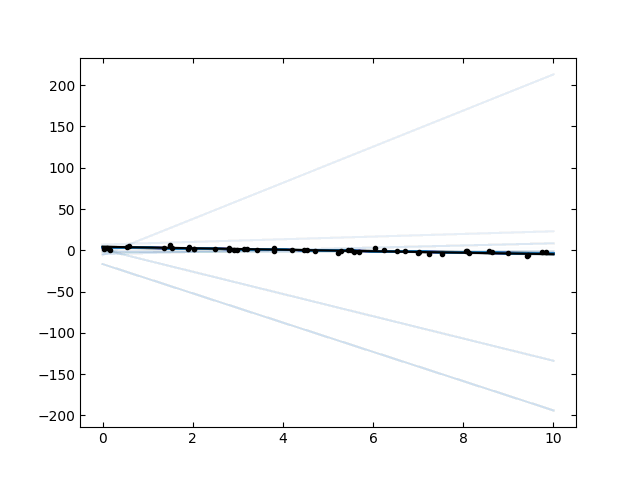

In [6]:
#ln(likelihood) function
def lnlike(params, x, y, yerr):
    """
    This is the likelihood. This function takes in an array of parameters, 
    as well as the values from our data vector (in this case x, y, and 
    the error on y). It returns the total log(likelihood), i.e. p(D | theta).
    """
    #model
    m, b, lnf = params
    model = m * x + b
    sigma2 = yerr ** 2 + model ** 2 * np.exp(2 * lnf)

    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))


#ln(prior). Simple uniform prior in this case
def lnprior(params):
    """
    This is the prior. This function takes in an array of parameters, and returns
    the associated likelihood of those parameters independent of the data.
    """
    m, b, lnf = params
    #the prior here is relatively simple: it applies a uniform weighting to both
    #the slope and the intercept. 
    if -5.0 < m < 5.0 and -10 < b < 10.0 and -6 < lnf < 6:
        return 0.0 #ln(prior)
    return -np.inf

#ln(probability). Just a combination of the liklihood and prior
def lnprob(params, x, y, yerr):
    """
    This defines the posterior. Following Bayes' Theorem, the posterior is just the 
    product of the prior and the likelihood. Conveniently, this is just a sum on log-space."""
    lp = lnprior(params)
    
    #This ensures that points outside the prior are avoided.
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(params, x, y, yerr) #ln(probability)


####### This block is initializing the MCMC sampler ########
ndim = 3 #number of dimensions
nwalkers = 50 #number of walkers to run parallel MCMC chains
n_burnin = int(1000) #number of samples to generate for burn-in
n_chain = int(3000) #number of samples to generate for production
########################################

#make a starting point as a broad ball of random numbers
a_init = 10*np.random.standard_normal(size=(nwalkers,ndim))

#initialise and run the sampler for burn-in
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(x, y, yerr))
pos, lnprob, state = sampler.run_mcmc(a_init, n_burnin)

#NB: The burn-in step is important, as in most cases we'll be initialising our
#walkers at some part of the posterior parameter space that _is not_ the where 
#we ultimately want to draw samples from. Discarding the burn-in ensures that 
#we don't include these samples in our statistics.

#look at the chains in m and b
fig, ax = plt.subplots(3, figsize=(6, 5), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "lnf"]
for i in range(ndim):
    ax[i].plot(samples[:, :, i], "k", alpha=0.3)
    ax[i].set_xlim(0, len(samples))
    ax[i].set_ylabel(labels[i])
    ax[i].yaxis.set_label_coords(-0.1, 0.5)

ax[-1].set_xlabel("step number")
ax[0].set_title("burn-in chains")
plt.show()

# #Take chains at the lowest likelihood and re-assign them the position
# #and likelihood of the current highest likelihood chain. This can help
# #to avoid walkers getting "stuck" in some part of the parameter space.
# best_chain = np.argmax(lnprob)
# poor_chains = np.where(lnprob < np.percentile(lnprob, 25))
# for ix in poor_chains:
#     pos[ix] = pos[best_chain]
    
# #Reset and run again
# sampler.reset()
# pos, lnprob, state = sampler.run_mcmc(pos, n_burnin, skip_initial_state_check=True)

#run again
sampler.reset()
sampler.run_mcmc(pos, n_chain, skip_initial_state_check=True)


#look at the final chains in m and b
fig, ax = plt.subplots(3, figsize=(6, 5), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "lnf"]
for i in range(ndim):
    ax[i].plot(samples[:, :, i], "k", alpha=0.3)
    ax[i].set_xlim(0, len(samples))
    ax[i].set_ylabel(labels[i])
    ax[i].yaxis.set_label_coords(-0.1, 0.5)

ax[-1].set_xlabel("step number");
ax[0].set_title("production chains")
plt.show()

#check for convergence. Remember: variance for MCMC chains scales with the 
#autocorrelation length. Shorter is better, and you want to run samples for 
#at least 50 autocorrelation lengths with emcee.
print("Autocorrelation length: {0}".format(sampler.get_autocorr_time()[0]))

#Let's look at the corner plot for this
flat_samples = sampler.get_chain(discard=0, thin=10, flat=True)

#plot the 2d distribution
fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
)
plt.show()

#overplot some draws from the posterior
fig = plt.figure()
inds = np.random.randint(len(flat_samples), size=500)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x_ref, sample[0]*x_ref + sample[1], "C0", alpha=0.01)
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x_ref, m_true * x_ref + b_true, "k")
plt.show()

## Example code 2 - using dynesty

100%|███████████████████████████████████████████████████▉| 2355/2356 [00:04<00:00, 576.00it/s, +150 | bound: 49 | nc: 1 | ncall: 12987 | eff(%): 19.514 | loglstar: -40.993 | logz: -52.026 +/-  0.251 | dlogz:  0.000 >  0.010]


Bayesian evidence: -52.02584979045379


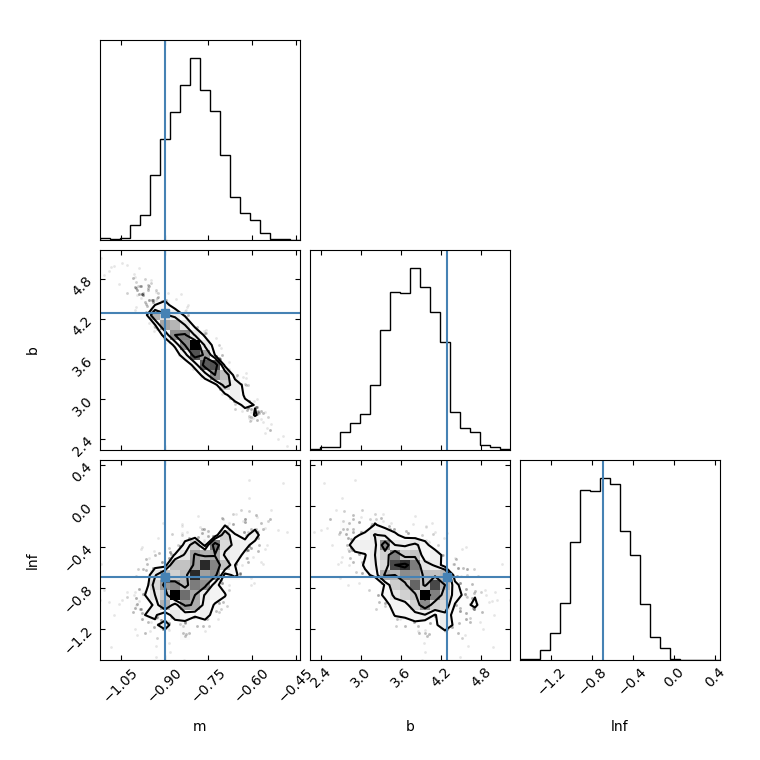

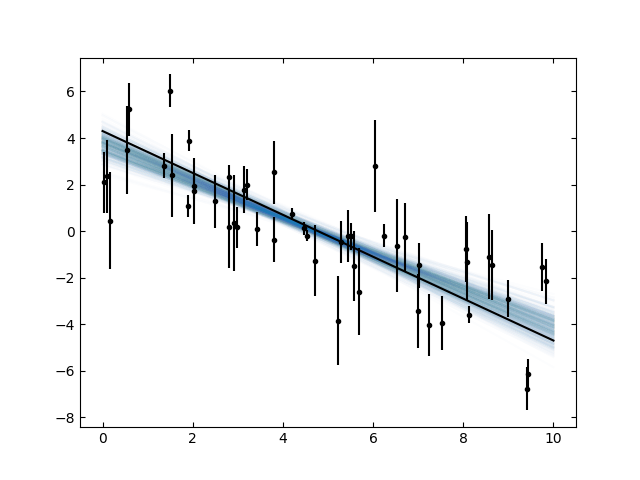

In [7]:
#likelihood is the same
def lnlike(params, x, y, yerr):
    """This funtion computes the likelihood, p(D|theta) and returns the 
    ln(likelihood). It takes as input the array of model parameters (theta in our 
    adopted notation), as well as the relevant data values (D).
    """ 
    ##simple case
    #m, b = params
    #model = m * x + b
    #sigma2 = yerr ** 2

    #more complicated case
    m, b, lnf = params
    model = m * x + b
    sigma2 = yerr ** 2 + model ** 2 * np.exp(2 * lnf)

    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

#instead of a direct prior, we define a set of transformations over the interval 0-1
def prior_transform(unit_cube):
    """This function transforms from uniform samples drawn over the 
    interval from 0 to 1 into the model parameter space (theta). 
    
    In the example here all priors are uniform, but they don't necessarily
    have to be.
    """
    #first make a copy of the input unit hypercube
    params = np.array(unit_cube)
    
    #prior on m, uniform between -5 and 5
    params[0] = sps.uniform.ppf(unit_cube[0], -5, 10)

    #prior on b, uniform between -10 and 10
    params[1] = sps.uniform.ppf(unit_cube[1], -10, 20)
    
    #prior on lnf, uniform between -6 and 6
    params[2] = sps.uniform.ppf(unit_cube[2], -6, 12)

    return params
    

####### This block is initializing the Nested Sampler ########
#Define some key variables.
ndim = 3
labels= ['m', 'b', 'lnf']
sampler = dynesty.NestedSampler(lnlike, prior_transform, ndim, 
                                logl_args=(x, y, yerr), nlive=150)
########################################


####### Run the sampler and extract some results ########
sampler.run_nested(dlogz=0.01)

# Extract sampling results.
results = sampler.results

#pull "dead" points, and weight by their associated likelihoods
samples = results.samples  
weights = np.exp(results.logwt - results.logz[-1])  # normalized weights

#print out the evidence for this model
print("Bayesian evidence: {0}".format(results.logz[-1]))

# Resample weighted samples.
samples_equal = utils.resample_equal(samples, weights)

# plot the equal weighted samples to draw posterior samples
#plot the 2d distribution
fig = corner.corner(
    samples_equal, labels=labels, truths=[m_true, b_true, np.log(f_true)])
plt.show()

fig, ax = plt.subplots()
#overlay draws from the posterior
x_ref = np.linspace(0,10, 100)
inds = np.random.randint(samples_equal.shape[0], size=500)
for ind in inds:
    sample = samples_equal[ind]
    ax.plot(x_ref, sample[0]*x_ref + sample[1], "C0", alpha=0.01)
ax.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
ax.plot(x_ref, m_true * x_ref + b_true, "k")
plt.show()



## Example 3: using numpyro and HMC

/var/folders/ww/mdbqvt316nv0l6pj8ll_vj880000gq/T/ipykernel_68170/33380923.py:25: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=2000, num_samples=2000, num_chains=4)
sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:01<00:00, 3322.97it/s, 49 steps of size 3.18e-02. acc. prob=0.78]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      0.62      1.85     -0.28     -0.94      4.03      2.04      6.69
       lnf      1.39      1.37      1.62     -1.00      3.17      2.22      3.10
         m     -0.19      0.36     -0.00     -0.85      0.11      2.03      7.63

Number of divergences: 198


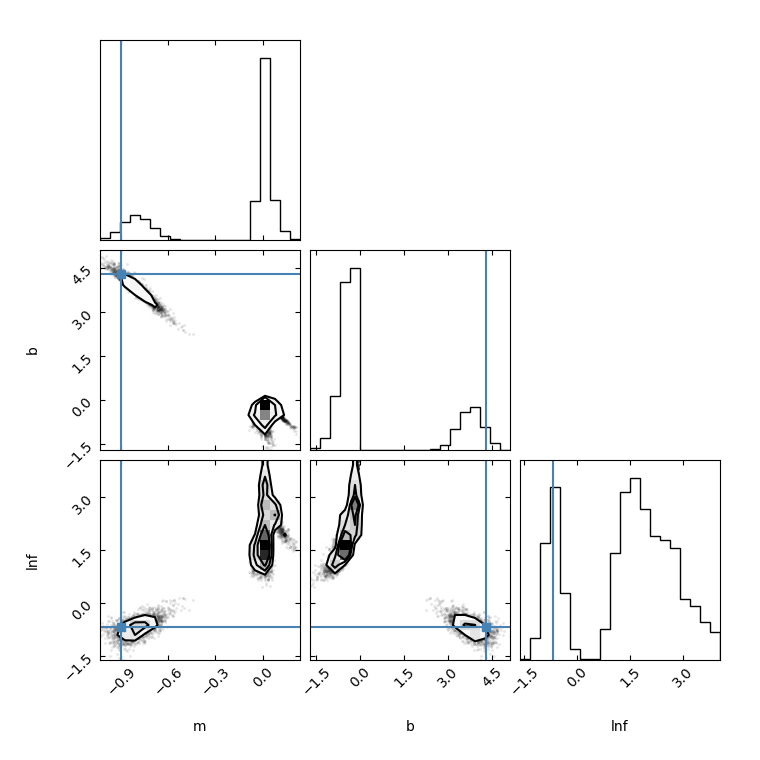

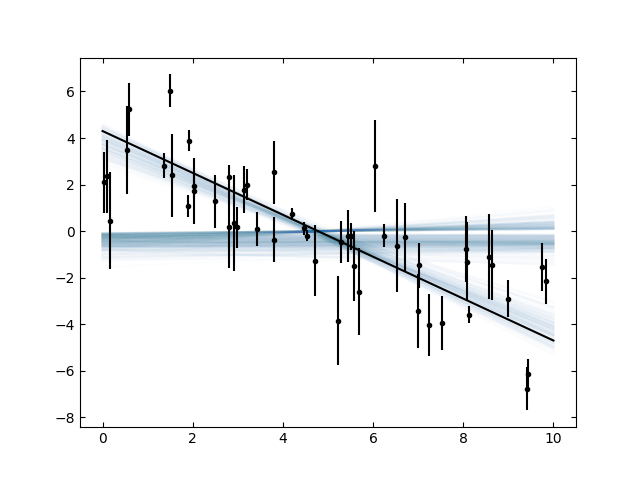

In [8]:
def model(x, y, yerr):
    """numpyro samples directly from within the model using defined prior
    distributions. This is distinct from emcee/dynesty, where the priors
    are explicitly defined as separate functions.
    """ 
    # prior on m, uniform between -5 and 5
    m = numpyro.sample("m", dist.Uniform(-5, 5))
    
    # prior on b, uniform between -10 and 10
    b = numpyro.sample("b", dist.Uniform(-10, 10))
    
    # prior on lnf, uniform between -6 and 6
    lnf = numpyro.sample("lnf", dist.Uniform(-6, 6))

    # Same as before, but calling jnp equivalent functions where needed
    model_y = m * x + b
    sigma2 = yerr ** 2 + model_y ** 2 * jnp.exp(2 * lnf)

    numpyro.sample("obs", dist.Normal(model_y, jnp.sqrt(sigma2)), obs=y)

####### This block is initializing the NUTS sampler ########
labels = ['m', 'b', 'lnf']

nuts_kernel = NUTS(model)
mcmc = MCMC(nuts_kernel, num_warmup=2000, num_samples=2000, num_chains=4)
########################################

####### Run the sampler and extract some results ########
jx = jnp.asarray(x)
jy = jnp.asarray(y)
jyerr = jnp.asarray(yerr)

rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key, x=jx, y=jy, yerr=jyerr)

mcmc.print_summary()          # r_hat, n_eff, mean/std for each parameter -- built in

samples = mcmc.get_samples()               # dict: {'m': array, 'b': array, 'lnf': array}

#reformat for corner plot
jresults = jnp.stack([samples[k] for k in labels], axis=-1) 


results = np.asarray(jresults)

#plot the 2d distribution
fig = corner.corner(
    results, labels=labels, truths=[m_true, b_true, np.log(f_true)])
plt.show()

fig, ax = plt.subplots()
#overlay draws from the posterior
x_ref = np.linspace(0,10, 100)
inds = np.random.randint(results.shape[0], size=500)
for ind in inds:
    sample = results[ind]
    ax.plot(x_ref, sample[0]*x_ref + sample[1], "C0", alpha=0.01)
ax.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
ax.plot(x_ref, m_true * x_ref + b_true, "k")
plt.show()


Dynesty is relatively robust to broad priors because it samples to entire prior volume by default 
(with enough live points). emcee and HMC can be sensitivity to the starting point. How about if we make an initial
guess of starting point just to narrow things in?

In [9]:
from scipy.optimize import curve_fit

def linear_model(x, m, b):
    return m * x + b

#estimate m and b from a simple linear fit
popt, pcov = curve_fit(linear_model, x, y, sigma=yerr, p0=[1.0, 0.0], method="lm")
m_init, b_init = popt

#estimate lnf from the scatter of points
f_init = np.log(np.std(linear_model(x, m_init, b_init))/np.std(y))

print("LM initial estimate:  m =", m_init, " b =", b_init, " lnf =", f_init)
init_array = np.array([m_init, b_init, f_init])

LM initial estimate:  m = -0.9000466902927978  b = 4.254760385676711  lnf = -0.01977529552883281


(50, 3)


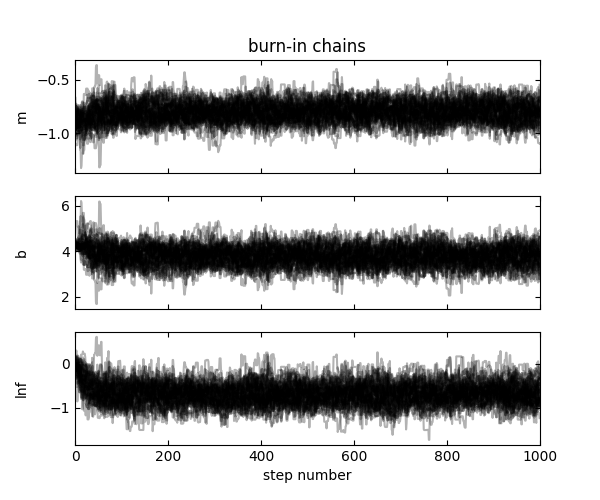

/var/folders/ww/mdbqvt316nv0l6pj8ll_vj880000gq/T/ipykernel_68170/2623033938.py:82: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(3, figsize=(6, 5), sharex=True)


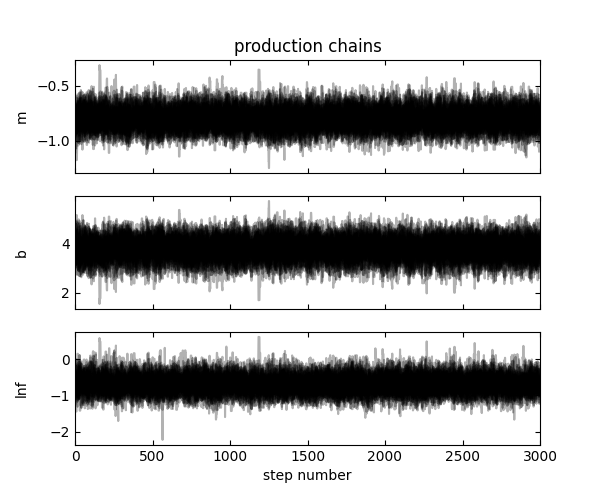

Autocorrelation length: 34.59078368347074


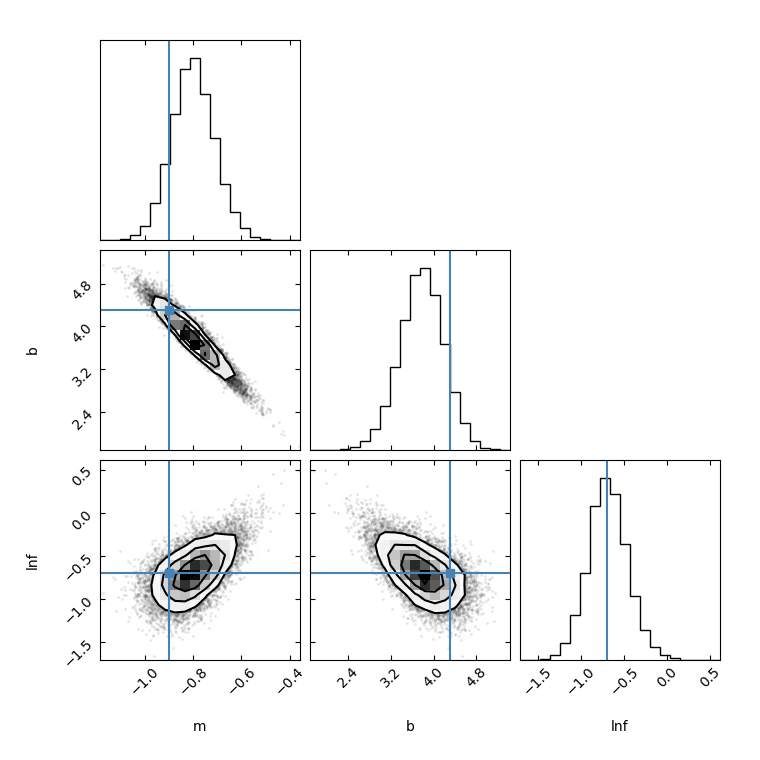

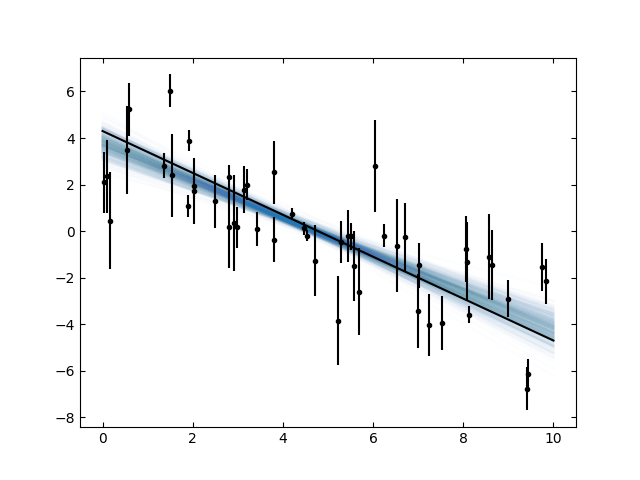

In [10]:
#emcee fix
#ln(likelihood) function
def lnlike(params, x, y, yerr):
    """
    This is the likelihood. This function takes in an array of parameters, 
    as well as the values from our data vector (in this case x, y, and 
    the error on y). It returns the total log(likelihood), i.e. p(D | theta).
    """
    #model
    m, b, lnf = params
    model = m * x + b
    sigma2 = yerr ** 2 + model ** 2 * np.exp(2 * lnf)

    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))


#ln(prior). Simple uniform prior in this case
def lnprior(params):
    """
    This is the prior. This function takes in an array of parameters, and returns
    the associated likelihood of those parameters independent of the data.
    """
    m, b, lnf = params
    #the prior here is relatively simple: it applies a uniform weighting to both
    #the slope and the intercept. 
    if -5.0 < m < 5.0 and -10 < b < 10.0 and -6 < lnf < 6:
        return 0.0 #ln(prior)
    return -np.inf

#ln(probability). Just a combination of the liklihood and prior
def lnprob(params, x, y, yerr):
    """
    This defines the posterior. Following Bayes' Theorem, the posterior is just the 
    product of the prior and the likelihood. Conveniently, this is just a sum on log-space."""
    lp = lnprior(params)
    
    #This ensures that points outside the prior are avoided.
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(params, x, y, yerr) #ln(probability)


####### This block is initializing the MCMC sampler ########
ndim = 3 #number of dimensions
nwalkers = 50 #number of walkers to run parallel MCMC chains
n_burnin = int(1000) #number of samples to generate for burn-in
n_chain = int(3000) #number of samples to generate for production
########################################

#make a starting point as a broad ball of random numbers
a_init = 0.1*np.random.standard_normal(size=(nwalkers,ndim)) + init_array[None,:]
print(a_init.shape)

#initialise and run the sampler for burn-in
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(x, y, yerr))
pos, lnprob, state = sampler.run_mcmc(a_init, n_burnin)

#NB: The burn-in step is important, as in most cases we'll be initialising our
#walkers at some part of the posterior parameter space that _is not_ the where 
#we ultimately want to draw samples from. Discarding the burn-in ensures that 
#we don't include these samples in our statistics.

#look at the chains in m and b
fig, ax = plt.subplots(3, figsize=(6, 5), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "lnf"]
for i in range(ndim):
    ax[i].plot(samples[:, :, i], "k", alpha=0.3)
    ax[i].set_xlim(0, len(samples))
    ax[i].set_ylabel(labels[i])
    ax[i].yaxis.set_label_coords(-0.1, 0.5)

ax[-1].set_xlabel("step number")
ax[0].set_title("burn-in chains")
plt.show()

#run again
sampler.reset()
sampler.run_mcmc(pos, n_chain, skip_initial_state_check=True)

#look at the final chains in m and b
fig, ax = plt.subplots(3, figsize=(6, 5), sharex=True)
samples = sampler.get_chain()
labels = ["m", "b", "lnf"]
for i in range(ndim):
    ax[i].plot(samples[:, :, i], "k", alpha=0.3)
    ax[i].set_xlim(0, len(samples))
    ax[i].set_ylabel(labels[i])
    ax[i].yaxis.set_label_coords(-0.1, 0.5)

ax[-1].set_xlabel("step number");
ax[0].set_title("production chains")
plt.show()

#check for convergence. Remember: variance for MCMC chains scales with the 
#autocorrelation length. Shorter is better, and you want to run samples for 
#at least 50 autocorrelation lengths with emcee.
print("Autocorrelation length: {0}".format(sampler.get_autocorr_time()[0]))

#Let's look at the corner plot for this
flat_samples = sampler.get_chain(discard=0, thin=10, flat=True)

#plot the 2d distribution
fig = corner.corner(
    flat_samples, labels=labels, truths=[m_true, b_true, np.log(f_true)]
)
plt.show()

#overplot some draws from the posterior
fig = plt.figure()
inds = np.random.randint(len(flat_samples), size=500)
for ind in inds:
    sample = flat_samples[ind]
    plt.plot(x_ref, sample[0]*x_ref + sample[1], "C0", alpha=0.01)
plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x_ref, m_true * x_ref + b_true, "k")
plt.show()

/var/folders/ww/mdbqvt316nv0l6pj8ll_vj880000gq/T/ipykernel_68170/2225740245.py:29: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(nuts_kernel, num_warmup=2000, num_samples=2000, num_chains=4)
sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 4946.85it/s, 19 steps of size 2.23e-01. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      3.78      0.42      3.79      3.09      4.48   1951.21      1.00
       lnf     -0.70      0.24     -0.70     -1.10     -0.31   1834.93      1.00
         m     -0.80      0.09     -0.80     -0.95     -0.65   2021.54      1.00

Number of divergences: 0


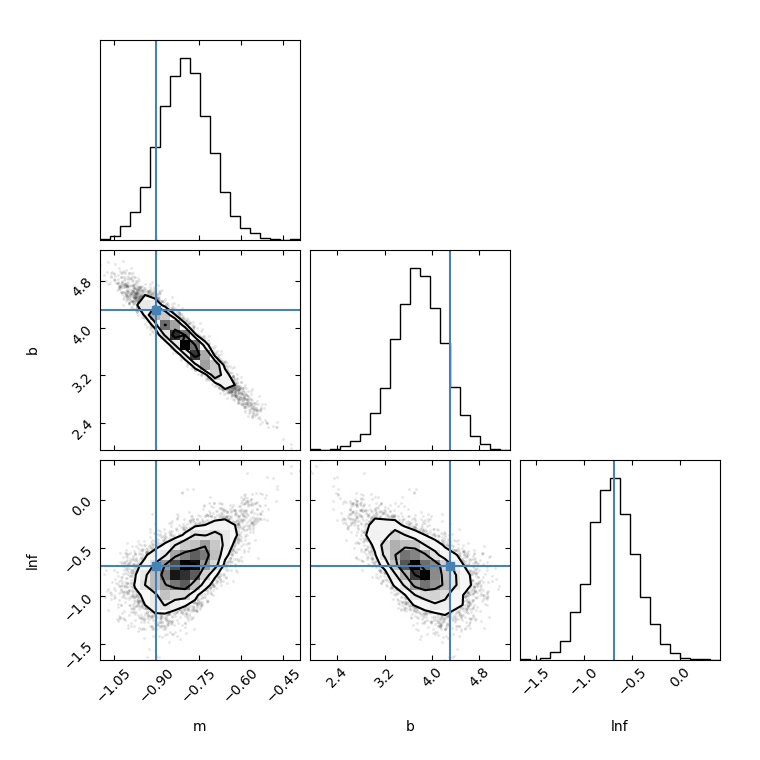

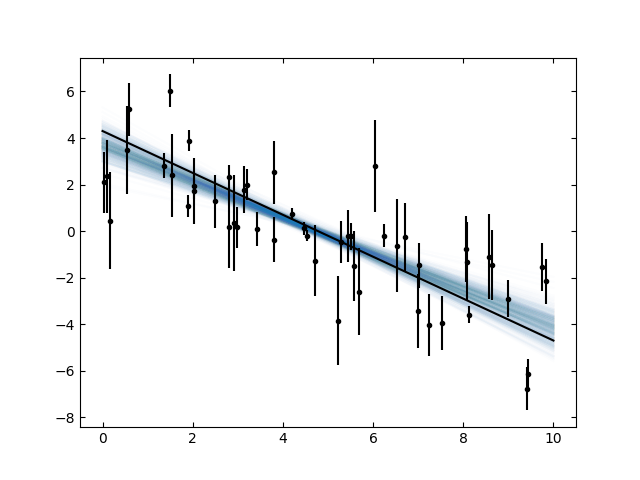

In [11]:
#hmc fix
from numpyro.infer import init_to_value

def model(x, y, yerr):
    """numpyro samples directly from within the model using defined prior
    distributions. This is distinct from emcee/dynesty, where the priors
    are explicitly defined as separate functions.
    """ 
    # prior on m, uniform between -5 and 5
    m = numpyro.sample("m", dist.Uniform(-5, 5))
    
    # prior on b, uniform between -10 and 10
    b = numpyro.sample("b", dist.Uniform(-10, 10))
    
    # prior on lnf, uniform between -6 and 6
    lnf = numpyro.sample("lnf", dist.Uniform(-6, 6))

    # Same as before, but calling jnp equivalent functions where needed
    model_y = m * x + b
    sigma2 = yerr ** 2 + model_y ** 2 * jnp.exp(2 * lnf)

    numpyro.sample("obs", dist.Normal(model_y, jnp.sqrt(sigma2)), obs=y)

####### This block is initializing the NUTS sampler ########
labels = ['m', 'b', 'lnf']
init_dict = dict(zip(labels, init_array))

nuts_kernel = NUTS(model, init_strategy=init_to_value(values=init_dict))
mcmc = MCMC(nuts_kernel, num_warmup=2000, num_samples=2000, num_chains=4)
########################################

####### Run the sampler and extract some results ########
jx = jnp.asarray(x)
jy = jnp.asarray(y)
jyerr = jnp.asarray(yerr)

rng_key = jax.random.PRNGKey(0)
mcmc.run(rng_key, x=jx, y=jy, yerr=jyerr)

mcmc.print_summary()          # r_hat, n_eff, mean/std for each parameter -- built in

samples = mcmc.get_samples()               # dict: {'m': array, 'b': array, 'lnf': array}

#reformat for corner plot
jresults = jnp.stack([samples[k] for k in labels], axis=-1) 

#convert to numpy array to keep other things happy
results = np.asarray(jresults)

#plot the 2d distribution
fig = corner.corner(
    results, labels=labels, truths=[m_true, b_true, np.log(f_true)])
plt.show()

fig, ax = plt.subplots()
#overlay draws from the posterior
x_ref = np.linspace(0,10, 100)
inds = np.random.randint(results.shape[0], size=500)
for ind in inds:
    sample = results[ind]
    ax.plot(x_ref, sample[0]*x_ref + sample[1], "C0", alpha=0.01)
ax.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
ax.plot(x_ref, m_true * x_ref + b_true, "k")
plt.show()
